# Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\Downloads\EL-Project1\imdb_movies.csv")
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


# Data Cleaning

In [5]:
df = df[['names','score','genre','overview','budget_x','revenue']]

df.dropna(inplace=True)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

df.dropna(inplace=True)

# Sentiment Analysis (VADER)

In [8]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['overview'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


In [10]:
def label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(label)

# Sentiment Visualization

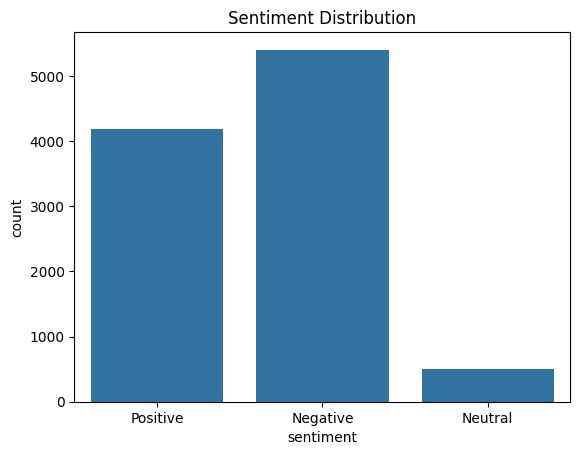

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Genre vs Sentiment

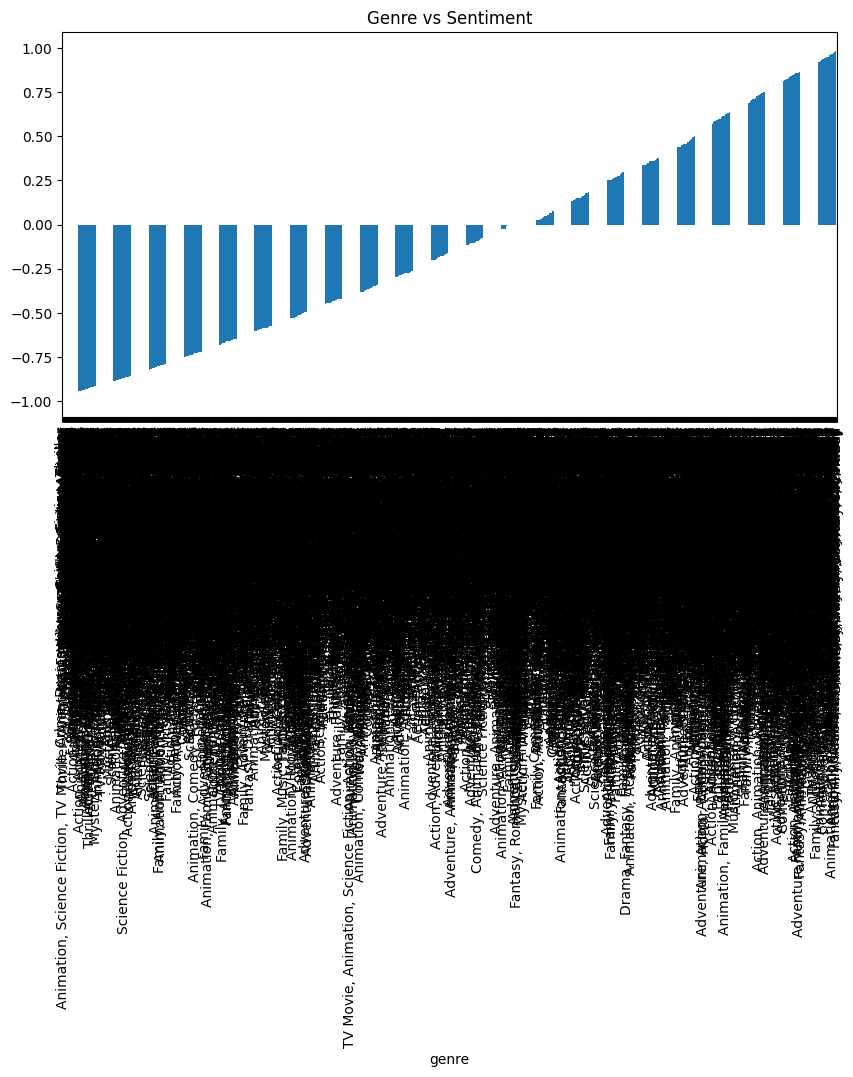

In [16]:
genre_sentiment = df.groupby('genre')['sentiment_score'].mean().sort_values()

genre_sentiment.plot(kind='bar', figsize=(10,5))
plt.title("Genre vs Sentiment")
plt.show()

# Movie Success Prediction Model

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['budget_x','score','sentiment_score']]
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 139097181.5505683
R2: 0.5061027007969567


# Prediction Visualization

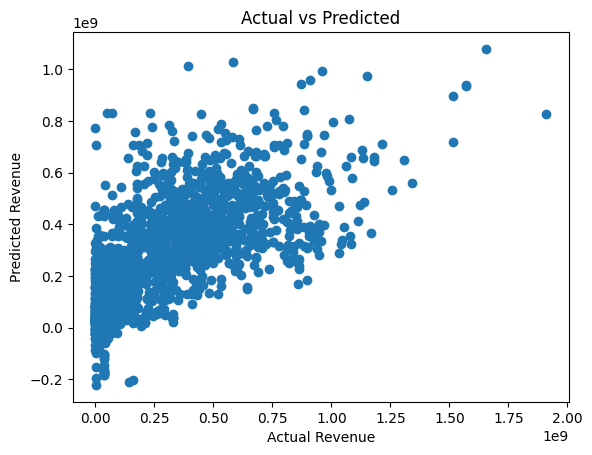

In [22]:
plt.scatter(y_test, pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted")
plt.show()

# Correlation Heatmap

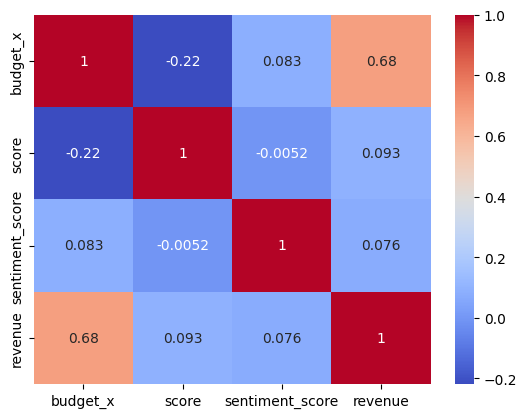

In [25]:
sns.heatmap(df[['budget_x','score','sentiment_score','revenue']].corr(),
            annot=True, cmap='coolwarm')
plt.show()

In [27]:
df.to_excel("movie_analysis.xlsx", index=False)

**Performed sentiment analysis on IMDb movie data using NLP (VADER) and developed a machine learning model to predict box office revenue based on budget, rating, and sentiment features.**